# Archelec — Topic Modeling sur l'extrême droite (1981–1988–1993)

## Contexte de recherche

Ce notebook analyse les **professions de foi** (PF) des candidats d'extrême droite aux élections législatives françaises de **1981, 1988 et 1993**, issues du corpus Archelec (CEVIPOF / Sciences Po).

### Questions de recherche
1. Quels sont les **grands thèmes** abordés par l'extrême droite dans ses professions de foi ?
2. Y a-t-il une **évolution** entre 1981, 1988 et 1993 ?
3. Y a-t-il des **persistances** ? Des thèmes récurrents sur toute la période ?

### Arborescence du projet
```
NLP_PROJECT/
  data/
    text_files/
      1981/
        legislatives/     ← fichiers .txt nommés EL***_L_1981_..._PF_**.txt
        presidentielle/
      1988/
        legislatives/
      1993/
        legislatives/
```

### Convention de nommage des fichiers
```
EL134_L_1981_06_001_01_1_PF_01.txt
 [0]  [1] [2] [3] [4] [5][6][7][8]
  │    │   │   │   │   │  │  │  └─ Numéro candidat dans la circo
  │    │   │   │   │   │  │  └──── Type document (PF = Profession de Foi)
  │    │   │   │   │   │  └─────── Tour (1 ou 2)
  │    │   │   │   │   └────────── Numéro de circonscription
  │    │   │   │   └────────────── Numéro de département (001 = Ain)
  │    │   │   └────────────────── Mois de l'élection
  │    │   └────────────────────── Année
  │    └────────────────────────── Type élection (L = Législatives)
  └─────────────────────────────── Identifiant Archelec
```

### Contexte historique
- **1981** : Le FN est quasi-inexistant (0,18% des voix). Très peu de candidats présentés.
- **1988** : 14,4% à la présidentielle 1988 pour JM LE PEN, le FN est commence à s'ancrer dans le paysage. 
- **1993** : Le FN obtient 12,5% au 1er tour. Période de consolidation idéologique (immigration, insécurité, anti-système).

---
## Étape 0 — Imports et configuration

In [ ]:
import os, re, unicodedata, textwrap
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ── Chemin racine du projet ───────────────────────────────────────────────────
PROJECT_ROOT   = Path('.')
TEXT_FILES_DIR = PROJECT_ROOT / 'data' / 'text_files'
YEARS          = [1981, 1988, 1993]

# Affichage de l'arborescence et du nombre de fichiers
print(f"Racine du projet : {PROJECT_ROOT.resolve()}")
for year in YEARS:
    p = TEXT_FILES_DIR / str(year) / 'legislatives'
    if p.exists():
        n = len(list(p.glob('*.txt')))
        print(f"  {year}/legislatives/ → {n} fichiers .txt")
    else:
        print(f"  année {p} introuvable !")

Racine du projet : C:\Users\jonas\OneDrive - GENES\Documents\0 ENSAE\3A\S2\ML_for_NLP\NLP_project
  1981/legislatives/ → 3182 fichiers .txt
  1988/legislatives/ → 3628 fichiers .txt
  1993/legislatives/ → 5936 fichiers .txt


---
## Étape 1 — Chargement des fichiers texte et préparation des données

On charge tous les fichiers `.txt` des dossiers `legislatives/` et on pré-traite les métadonnées encodées dans le nom de fichier (département, circonscription, tour, numéro de candidat ; cf. introduction du notebook pour plus de détails).

La fonction _parse_filename_ permet de mettre en forme correctement les méta données à partir du nom des fichiers.

La fonction _load_corpus_ charge les professions de foi uniquement. Elle appelle également la fonction _parse_filename_ pour créer les méta données.

In [ ]:
def parse_filename(filepath):
    """
    Mise en forme du nom de fichier Archelec pour créer des méta données :
      EL134_L_1981_06_001_01_1_PF_01.txt
      EL134_L_1981_06_02A_01_1_PF_01.txt  ← Corse (dep alphanumérique)
      EL134_L_1981_06_013_10_1_BV_pdfmasterocr.txt  ← ignoré (pas une PF)
    """
    name  = Path(filepath).stem
    parts = name.split('_')
    
    try:
        doc_type = parts[7]   # permet d'accéder à la catégorie PF = professions de foi
        
        # Numéro de candidat : peut être 'pdfmasterocr' pour les BV mal nommés
        # → on met None, le filtre doc_type != 'PF' les éliminera de toute façon
        try:
            candidat_num = int(parts[8])
        except (ValueError, IndexError):
            candidat_num = None

        # Département : peut être '001', '02A', '02B' (Corse)
        dep_raw = parts[4]
        if dep_raw.upper() in ('02A', '2A'):
            dep = '2A'   # Corse-du-Sud
        elif dep_raw.upper() in ('02B', '2B'):
            dep = '2B'   # Haute-Corse
        else:
            dep = int(dep_raw)   # cas normal : entier

        return {
            'archelec_id'  : parts[0],
            'election_type': parts[1],
            'year'         : int(parts[2]),
            'month'        : parts[3],
            'dep'          : dep,
            'circ'         : int(parts[5]),
            'tour'         : int(parts[6]),
            'doc_type'     : doc_type,
            'candidat_num' : candidat_num,
        }

    except (IndexError, ValueError) as e:
        print(f"Parsing échoué pour '{name}' : {e}")
        return {k: None for k in
                ['archelec_id','election_type','year','month',
                 'dep','circ','tour','doc_type','candidat_num']}

def load_corpus(text_files_dir, years):
    """
    Charge les fichiers .txt dans text_files/{année}/legislatives/
    Ne conserve que les documents de type PF (Profession de Foi).
    """
    records = []
    for year in years:
        folder = Path(text_files_dir) / str(year) / 'legislatives'
        if not folder.exists():
            print(f"Dossier manquant : {folder}") ; continue

        n_pf = n_skip = 0
        for fpath in sorted(folder.glob('*.txt')):
            meta = parse_filename(fpath)

            # On ne garde que les Professions de Foi
            if meta['doc_type'] != 'PF':
                n_skip += 1 ; continue

            # Lecture avec le bon encodage
            try:
                text = fpath.read_text(encoding='utf-8')
            except UnicodeDecodeError:
                text = fpath.read_text(encoding='latin-1')

            text = text.strip()
            records.append({
                'filename'     : fpath.name,
                'archelec_id'  : meta['archelec_id'],
                'year'         : year,
                'dep'          : meta['dep'],
                'circ'         : meta['circ'],
                'tour'         : meta['tour'],
                'candidat_num' : meta['candidat_num'],
                'text'         : text,
                'text_length'  : len(text),
            })
            n_pf += 1

        print(f"{year} : {n_pf} PF chargées  ({n_skip} fichiers non-PF ignorés)")

    return pd.DataFrame(records)


# Création du corpus
df_all = load_corpus(TEXT_FILES_DIR, YEARS)

# Quelques statistiques de base
print(f"\n Corpus total : {len(df_all)} professions de foi")
print("\nLongueur des textes (caractères) :")
print(df_all.groupby('year')['text_length']
      .describe()[['min','mean','max']].round(0))

1981 : 3124 PF chargées  (58 fichiers non-PF ignorés)
1988 : 3544 PF chargées  (84 fichiers non-PF ignorés)
Parsing échoué pour 'EL195_L_1993_03_75__03_1_TR_02' : invalid literal for int() with base 10: ''
1993 : 5840 PF chargées  (96 fichiers non-PF ignorés)

 Corpus total : 12508 professions de foi

Longueur des textes (caractères) :
        min    mean      max
year                        
1981  673.0  4197.0  22128.0
1988  377.0  3507.0  15489.0
1993  168.0  4171.0  50611.0


---
## Étape 2 — Identification des professions de foi d'extrême droite

Pour identifier les professions de foi d'extrème droite on utilise les méta données (table _metadata_) disponibles en ligne que l'on lie avec le corpus. Ensuite, on filtre sur le nom des partis d'extrème droite rattachés au candidat (soit le parti auquel il est rattaché, soit le parti qui le soutient).

In [ ]:
# ═══════════════════════════════════════════════════════════════════════════
# ÉTAPE 2 — Identification des PF d'extrême droite via les métadonnées
# ═══════════════════════════════════════════════════════════════════════════
#
# La table metadata contient la colonne 'titulaire-liste' avec le nom du parti.


import pandas as pd

# ── 1. Chargement de la table de métadonnées ──────────────────────────────────
# Adapter le chemin et le séparateur selon votre fichier
# (souvent un .csv ou .tsv exporté depuis la base Archelec)
META_PATH = 'data/meta_data.csv'   # ← adapter si nécessaire

df_meta = pd.read_csv(META_PATH, sep=',', encoding='utf-8', low_memory=False)

print(f"Métadonnées chargées : {len(df_meta)} lignes")
print(f"Colonnes : {list(df_meta.columns)}\n")

# Affichage d'une partie de la table
print("Aperçu des colonnes 'titulaire-liste' et 'titulaire-soutien' :")
print(df_meta[['id','titulaire-liste','titulaire-soutien']].head(5).to_string())

Métadonnées chargées : 33031 lignes
Colonnes : ['id', 'date', 'subject', 'title', 'contexte-election', 'contexte-tour', 'cote', 'departement', 'departement-nom', 'departement-insee', 'identifiant de circonscription', 'images', 'pdf', 'ocr_url', 'titulaire-nom', 'titulaire-prenom', 'titulaire-sexe', 'titulaire-age', 'titulaire-age-calcule', 'titulaire-age-tranche', 'titulaire-profession', 'titulaire-mandat-en-cours', 'titulaire-mandat-passe', 'titulaire-associations', 'titulaire-autres-statuts', 'titulaire-soutien', 'titulaire-liste', 'titulaire-decorations', 'suppleant-nom', 'suppleant-prenom', 'suppleant-sexe', 'suppleant-age', 'suppleant-age-calcule', 'suppleant-age-tranche', 'suppleant-profession', 'suppleant-mandat-en-cours', 'suppleant-mandat-passe', 'suppleant-associations', 'suppleant-autres-statuts', 'suppleant-soutien', 'suppleant-liste', 'suppleant-decorations']

Aperçu des colonnes 'titulaire-liste' et 'titulaire-soutien' :
                               id titulaire-liste  

On affiche le nom de tous les partis afin d'identifier ceux d'extrème droite. On enregistre les partis d'extrème droite dans la cellule suivante. 

In [6]:
print(df_meta['titulaire-liste'].value_counts().to_string())    

titulaire-liste
non mentionné                                                                                                                                       15320
Union du rassemblement et du centre                                                                                                                   813
Majorité présidentielle pour la France unie                                                                                                           770
Union pour une nouvelle majorité                                                                                                                      708
Ve République                                                                                                                                         602
Union pour la défense de la République                                                                                                                570
Entente des écologistes                                     

In [ ]:
# ── 2. Définition des partis et soutiens d'extrême droite ─────────────────────
ED_PARTIS = {
    # Front National et variantes
    'Front national',
    'Front National',
    'Front national pour l\'unité française',
    'Front National pour l\'Unité Française',
    'Front national de la jeunesse',
    'Front national populaire',                                                                                                                              

    # Parti des Forces Nouvelles (rival du FN en 1981, même famille)
    'Parti des forces nouvelles',
    'Parti des Forces Nouvelles',
    'PFN',

    # Autres étiquettes d'extrême droite de la période
    'Rassemblement national',
    'Ordre nouveau',
    'Mouvement nationaliste révolutionnaire',
    'Faisceaux nationalistes européens',
    'Parti nationaliste français',
    'Rassemblement des forces nationales'
}

La fonction _is_extreme_droite_ permet de s'avoir si un candidat est d'extrème droite en comparant son parti et son soutient à la liste que l'on a identifié ci-dessus.


Colonnes mergées : ['id', 'titulaire-nom', 'titulaire-prenom', 'titulaire-liste', 'titulaire-soutien']
Matchés : 12497 / 12508
 11 fichiers sans métadonnées
Exemples : ['EL134_L_1981_06_015_01_2_PF_pdfmasterocr.txt', 'EL137_L_1981_06_077_02_2_PF_pdfmasterocr.txt', 'EL137_L_1981_06_092_04_1_PF_pdfmasterocr.txt']

'is_ed' présente : True
Candidats ED : 1257

Répartition des partis ED :
titulaire-liste
non mentionné                                   665
Liste entente populaire et nationale            395
Liste d'entente populaire et nationale          149
Rassemblement pour les libertés et la patrie     33
Union de la droite                                9
Union nationale                                   2
Pour un authentique socialisme                    1
Projet nationaliste européen                      1
Union de l'opposition nationale                   1
Opposition                                        1

 Corpus ED final : 1257 professions de foi
year
1981     58
1988    548
199

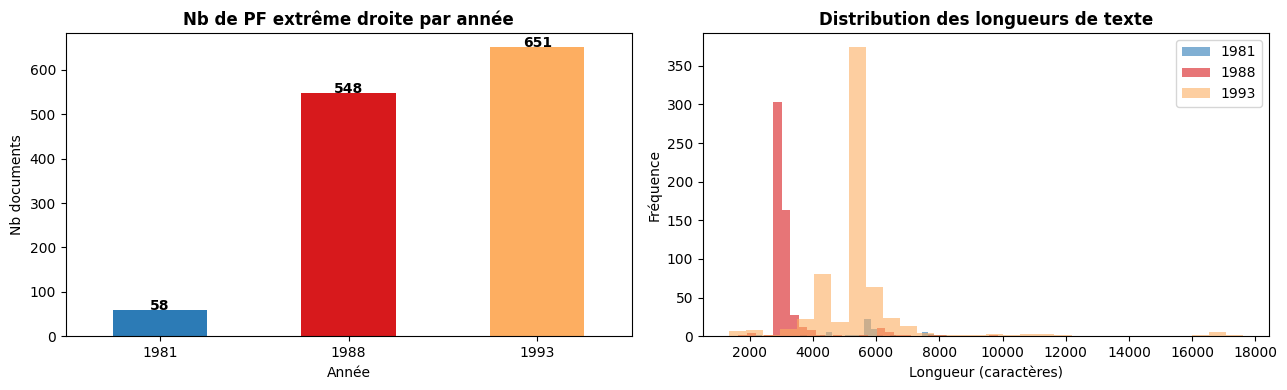


APERÇU — 3 exemples de PF extrême droite identifiées

[1988 | non mentionné Barlemont | Parti : Liste entente populaire et nationale]
Sciences Po / fonds CEVIPOF ELECTIONS LEGISLATIVES DE JUIN' 1988 - 5 CIRCONSCRIPTION DE
LA SARTHE 7 raisons de voter pour le candidat du Front National J.C BARLEMONT Ingénieur-
Secrétaire Départemental du F.N Suppléant : Marcel de COSSE BRISSAC Exploitant Agricole
Si vous voulez un député · qui soit présent à l'Assemblée nationale et qui remplisse
effectivement le mandat pour lequel les contribuabl

[1988 | André Isoardo | Parti : Liste d'entente populaire et nationale]
Sciences Po / fonds CEVIPOF 7 raisons de voter pour le candidat du Front National
Quatrième circonscription André ISOARDO 51 ans, Agent E.D.F. Conseiller Régional Membre
du Bureau du Conseil Régional Remplaçant éventuel : Gilbert ALBANO 50 ans, Docker Si
vous voulez un député · qui soit présent à l'Assemblée nationale et qui remplisse
effectivement le mandat pour lequel les contribuables

In [ ]:
def is_extreme_droite(liste_val, soutien_val):
    """
    Vérifie 'titulaire-liste' ET 'titulaire-soutien'.
    Comparaison insensible à la casse.
    """
    for val in [liste_val, soutien_val]:
        if pd.isna(val): continue
        v = str(val).lower().strip()
        if v in ('non mentionné', '', 'nan'): continue
        if v in ED_PARTIS: return True
        if 'front national' in v: return True
        if 'parti des forces nouvelles' in v: return True
    return False

# ── 3. Merge df_all + métadonnées ─────────────────────────────────────────────
df_all['id'] = df_all['filename'].str.replace('.txt', '', regex=False)

COLS_MERGE = ['id', 'titulaire-nom', 'titulaire-prenom',
              'titulaire-liste', 'titulaire-soutien']
COLS_MERGE = [c for c in COLS_MERGE if c in df_meta.columns]
print(f"\nColonnes mergées : {COLS_MERGE}")

df_merged = df_all.merge(df_meta[COLS_MERGE], on='id', how='left')

n_matched   = df_merged['titulaire-liste'].notna().sum()
n_unmatched = df_merged['titulaire-liste'].isna().sum()
print(f"Matchés : {n_matched} / {len(df_merged)}")
if n_unmatched > 0:
    print(f" {n_unmatched} fichiers sans métadonnées")
    print("Exemples :", df_merged[df_merged['titulaire-liste'].isna()]['filename'].head(3).tolist())

# ── 4. Calcul de is_ed APRÈS le merge ─────────────────────────────────────────
df_merged['is_ed'] = df_merged.apply(
    lambda row: is_extreme_droite(
        row.get('titulaire-liste'),
        row.get('titulaire-soutien')
    ), axis=1
)

print(f"\n'is_ed' présente : {'is_ed' in df_merged.columns}")
print(f"Candidats ED : {df_merged['is_ed'].sum()}")
print("\nRépartition des partis ED :")
print(df_merged[df_merged['is_ed']]['titulaire-liste'].value_counts().to_string())

# ── 5. Corpus final ───────────────────────────────────────────────────────────
MIN_CHARS = 300
df_ed = (df_merged[df_merged['is_ed'] == True]
         .query('text_length >= @MIN_CHARS')
         .copy()
         .reset_index(drop=True))

print(f"\n Corpus ED final : {len(df_ed)} professions de foi")
print(df_ed['year'].value_counts().sort_index())

n_1981 = (df_ed['year'] == 1981).sum()
if n_1981 < 10:
    print(f"\n  Seulement {n_1981} doc(s) pour 1981 — cohérent historiquement.")


On termine cette partie sur l'import de nos données en visualisant la répartitions des professions de foi d'extrème droite, leur logueur selon les années et quelques exemples identifiés.

In [ ]:
# ── 6. Visualisation ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = ['#2c7bb6', '#d7191c', '#fdae61']

counts = df_ed['year'].value_counts().sort_index()
counts.plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Nb de PF extrême droite par année', fontweight='bold')
axes[0].set_xlabel('Année') ; axes[0].set_ylabel('Nb documents')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(counts):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

for year, color in zip([1981, 1988, 1993], colors):
    sub = df_ed[df_ed['year'] == year]['text_length']
    if len(sub) > 0:
        axes[1].hist(sub, bins=30, alpha=0.6, label=str(year), color=color)
axes[1].set_title('Distribution des longueurs de texte', fontweight='bold')
axes[1].set_xlabel('Longueur (caractères)') ; axes[1].set_ylabel('Fréquence')
axes[1].legend()

plt.tight_layout()
plt.savefig('corpus_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── 7. Aperçu qualitatif ──────────────────────────────────────────────────────
print("\n" + "="*65)
print("APERÇU — 3 exemples de PF extrême droite identifiées")
print("="*65)
for _, row in df_ed.sample(n=min(3, len(df_ed)), random_state=42).iterrows():
    print(f"\n[{row['year']} | {row.get('titulaire-prenom','')} "
          f"{row.get('titulaire-nom','')} | Parti : {row['titulaire-liste']}]")
    print(textwrap.fill(row['text'][:400], width=88))

---
## Étape 3 — Prétraitement des textes

Avant de pouvoir faire le _topic modeling_, il faut :

**1. Nettoyager les textes** : les textes numérisées contiennent des éléments qui pourraient perturber l'analyse, on nettoie les textes par précaution. C'est également l'occasion de supprimer les _stop words_.

**2. Lemmatisation avec spaCy** : pour revenir à la racine des mots et avoir des analyses thématiques.

In [ ]:
import spacy

# ── 1. Nettoyage des textes ──────────────────────────────────────────────────────
def clean_ocr(text):
    """
    Nettoyage des artefacts spécifiques aux professions de foi Archelec numérisées.
    """
    # 1. Suppression des éléments  "Sciences Po / CEVIPOF"
    text = re.sub(r'sciences\s*po\s*/\s*fonds\s*cevipof', ' ', text, flags=re.I)
    text = re.sub(r'sciences\s*po', ' ', text, flags=re.I)
    text = re.sub(r'fonds\s*cevipof', ' ', text, flags=re.I)

    # 2. Suppression des symboles de cases à cocher
    text = re.sub(r'[☐□▢▪▫◻◼■●]', ' ', text)

    # 3. Suppressions des lignes de séparation graphique
    text = re.sub(r'[-=_*·]{3,}', ' ', text)

    # 4. Suppression des mentions d'imprimerie en fin de ligne
    text = re.sub(r'\bIMP[_\s][\w\s\.]+', ' ', text, flags=re.I)
    text = re.sub(r'\bIMPRIME[RIE\s]+[\w\s\.]+', ' ', text, flags=re.I)
    text = re.sub(r'\bPAPIER\s+R[EÉ]CUP[EÉ]R[EÉ][\w\s]+', ' ', text, flags=re.I)

    # 5. Suppression des numéros de page isolés
    text = re.sub(r'^\s*\d{1,2}\s*$', '', text, flags=re.M)

    # 6. Suppression des caractères non imprimables (sauf newline)
    text = ''.join(c for c in text
                   if unicodedata.category(c)[0] != 'C' or c == '\n')

    # 7. Suppression des espaces multiples
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


# Stopwords 
# On prend les stop words fournis par spaCy directement
# On commence par charger le modèle
nlp = spacy.load('fr_core_news_sm', disable=['parser', 'ner'])

# on récupère les stop words
SW_SPACY = set(nlp.Defaults.stop_words)

# On ajoute quelques Stopwords supplémentaires : termes présents dans TOUTES les PF
# quelle que soit l'orientation politique → non informatifs pour le topic modeling
SW_PF = {
    # Formules électorales génériques
    'voter', 'votez', 'vote', 'suffrage', 'suffrages', 'bulletin',
    # Termes institutionnels présents dans toutes les PF
    'candidat', 'candidature', 'circonscription', 'département',
    'député', 'suppléant', 'suppléante', 'assemblée', 'parlement',
    'élection', 'électeur', 'électeurs', 'électrice', 'électrices',
    'premier', 'second', 'tour', 'liste', 'programme',
    'cher', 'chère', 'monsieur', 'madame', 'citoyen', 'citoyens',
    # Termes géographiques génériques
    'france', 'français', 'française',
    # Verbes très génériques dans les PF
    'défendre', 'proposer', 'vouloir', 'permettre', 'assurer',
}

# on créer une liste avec l'ensemble des stop words.
ALL_SW = SW_SPACY | SW_PF

# ── 2. Lématisation des textes ──────────────────────────────────────────────────────
def lemmatize(text, nlp, stopwords):
    """
    Lemmatise le texte et filtre les stopwords, la ponctuation,
    les chiffres et les tokens trop courts.
    """
    doc = nlp(text[:100_000])
    return ' '.join(
        tok.lemma_.lower()
        for tok in doc
        if tok.is_alpha
        and not tok.is_stop
        and not tok.is_punct
        and not tok.is_space
        and len(tok.lemma_) >= 3
        and tok.lemma_.lower() not in stopwords
    )


# ── Application ───────────────────────────────────────────────────────────────
df_ed['text_clean'] = df_ed['text'].apply(clean_ocr)

print(f"Lemmatisation de {len(df_ed)} documents...")
df_ed['text_lemmatized'] = [
    lemmatize(t, nlp, ALL_SW) for t in df_ed['text_clean']
]


# On affiche un exemple de transformation
row = df_ed.iloc[0]
print(f"\n--- Exemple ({row['filename']}) ---")
print("ORIGINAL :")
print(textwrap.fill(row['text'][:400], 90))
print("\nAPRÈS NETTOYAGE + LEMMATISATION :")
print(textwrap.fill(row['text_lemmatized'][:400], 90))

Chargement du modèle spaCy fr_core_news_sm...
Nettoyage OCR...
Lemmatisation de 1257 documents...
Prétraitement terminé

--- Exemple (EL134_L_1981_06_002_02_1_PF_01.txt) ---
ORIGINAL :
Elections législatives DU 14 JUIN 1981 2e Circonscription de l'Aisne Rassemblement pour
les Libertés et la Patrie FRONT NATIONAL Président : Jean-Marie LE PEN CARON Daniel
Kinésithérapeute, 41 ans Marié, père de famille Un Picard pour des Picards Votre candidat
Suppléant : Paul MOLARD Commerçant, 38 ans Picardes, Picards, A force de faire avec les
voix de la droite, la politique de la gauche, M. G

APRÈS NETTOYAGE + LEMMATISATION :
election législatif juin aisne rassemblement liberté patrie front national président pen
caron daniel kinésithérapeute marié père famille picard picard paul molard commerçant
picardes picards force faire voix droite politique gauche giscard estaing majorité finir
faire élir président socialiste mitterrand élire majorité gauche grâce manœuvre diviser
majorité socialo communiste

---
## Étape 4 — LDA (Latent Dirichlet Allocation)

On utilise `CountVectorizer` (comptage brut) avec des **bigrammes** pour capturer les expressions composées caractéristiques de l'extrème droite (i.e. `préférence nationale`, `chômage immigrés`, `insécurité quotidienne`...).

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

N_FEATURES = 2000   # taille du vocabulaire
N_TOPICS   = 8      # nombre de sujets

# ── Vectorisation CountVectorizer ─────────────────────────────────────────────
# Choix des paramètres
# ngram_range=(1,2) : unigrammes ET bigrammes
# min_df=2          : un terme doit apparaître dans ≥2 documents (filtre le bruit OCR)
# max_df=0.9        : ignorer les termes dans >90% des docs (trop généraux)
tf_vectorizer = CountVectorizer(
    max_features=N_FEATURES,
    stop_words=list(ALL_SW),
    min_df=2, max_df=0.9,
    ngram_range=(1, 2)
)
tf_matrix = tf_vectorizer.fit_transform(df_ed['text_lemmatized'])

# ── Entraînement LDA ──────────────────────────────────────────────────────────
# On entraine le modèle sur nos données
lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    max_iter=20,
    learning_method='batch',
    random_state=42,
    n_jobs=-1
)
lda.fit(tf_matrix)

# On affiche les mots les plus importants pour chaque sujet
feat_names = tf_vectorizer.get_feature_names_out()

for i, topic in enumerate(lda.components_):
    top = [feat_names[j] for j in np.argsort(-topic)[:15]]
    print(f"\nTopic {i:02d} : {', '.join(top)}")

c:\Users\jonas\OneDrive - GENES\Documents\0 ENSAE\3A\S2\ML_for_NLP\NLP_project\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['neuf', 'qu', 'quelqu'] not in stop_words.
  warnings.warn(


Matrice document-terme : (1257, 2000)
→ 1257 documents × 2000 termes
Entraînement LDA...
✅ LDA entraîné  |  perplexité : 556.9

 TOPICS LDA — Extrême droite 1981–1993

Topic 00 : majorité, patrie, rassemblement, public, liberté patrie, falloir, liberté, présidentiel, président, sortant, rassemblement liberté, mitterrand, enseignement, giscard, économie

Topic 01 : die, der, und, main, impôt, sie, défense, mars, den, entreprise, für, suppression, franzosen, von, travail

Topic 02 : politique, gauche, liberté, entreprise, pouvoir, droite, public, loi, développer, sécurité, moyen, savoir, élire, justice, non

Topic 03 : force, vivre, conviction, confiance, avenir front, ici, suppression, force avenir, juin, république, mère, françois, mère famille, déclin, enseignement

Topic 04 : protéger, sécurité, priorité, impôt, réduire, rétablir, nationalité, sécurité social, code nationalité, sauver sécurité, priorité emploi, chèque, créer, réformer, étranger

Topic 05 : rétablir, impôt, million, c

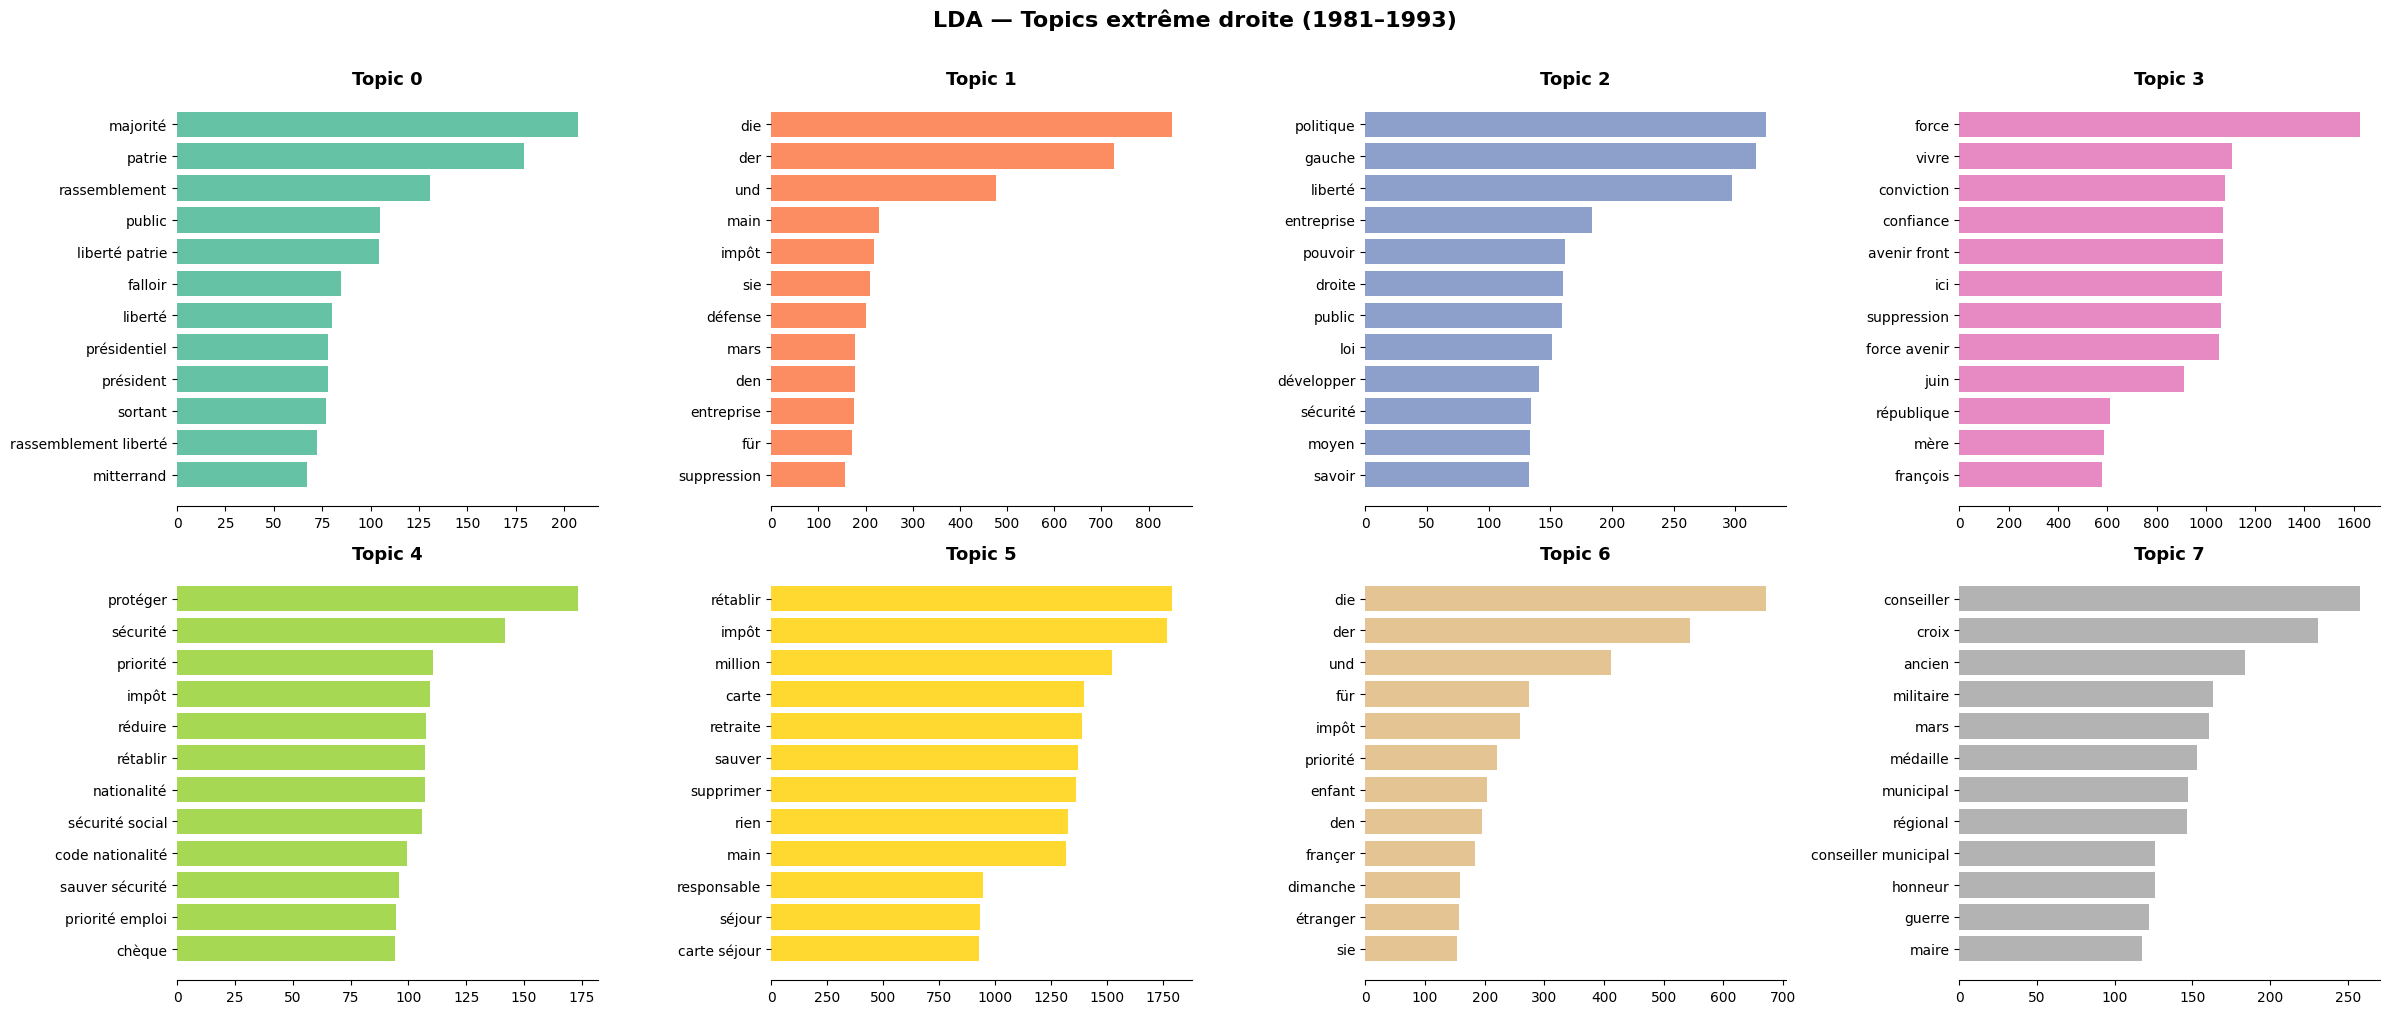

In [16]:
def plot_top_words(model, vectorizer, n_top, title, nb_cols=4):
    """Graphique en barres horizontales — top mots par topic."""
    fn   = vectorizer.get_feature_names_out()
    n_t  = len(model.components_)
    cols = min(nb_cols, n_t)
    rows = (n_t + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*6, rows*5))
    axes = axes.flatten() if n_t > 1 else [axes]
    pal  = plt.cm.Set2(np.linspace(0, 1, n_t))
    for idx, topic in enumerate(model.components_):
        top_i = topic.argsort()[-n_top:]
        ax    = axes[idx]
        ax.barh(fn[top_i], topic[top_i], color=pal[idx])
        ax.set_title(f"Topic {idx}", fontsize=13, fontweight='bold')
        ax.tick_params(labelsize=10)
        for sp in ['top','right','left']: ax.spines[sp].set_visible(False)
    for i in range(n_t, len(axes)): axes[i].set_visible(False)
    fig.suptitle(title, fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout() ; plt.show()


plot_top_words(lda, tf_vectorizer, 12,
               "LDA — Topics extrême droite (1981–1993)")

In [ ]:
import pyLDAvis, pyLDAvis.lda_model
pyLDAvis.enable_notebook()

# Visualisation interactive :
# • Taille des bulles = importance du topic dans le corpus
# • Distance entre bulles = similarité (topics proches = similaires)
pyLDAvis.lda_model.prepare(lda, tf_matrix, tf_vectorizer)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
5      0.244150 -0.048496       1        1  49.733439
3     -0.313161  0.070802       2        1  29.345518
1      0.226254 -0.086059       3        1   7.021431
6      0.103277 -0.012052       4        1   6.216278
2     -0.044374 -0.110964       5        1   3.795023
7     -0.114668 -0.077769       6        1   2.035758
4      0.061726  0.373719       7        1   1.080435
0     -0.163204 -0.109182       8        1   0.772117, topic_info=              Term         Freq        Total Category  logprob  loglift
1637      rétablir  2058.000000  2058.000000  Default  30.0000  30.0000
861          impôt  2435.000000  2435.000000  Default  29.0000  29.0000
401          créer  1570.000000  1570.000000  Default  28.0000  28.0000
1194   nationalité  1225.000000  1225.000000  Default  27.0000  27.0000
449            die  1513.000000  1513.000000  Default  26.0000  26.0000
...            ...          ...          ...      ...      ...      ...
1106    mitterrand    64.905368   735.829496   Topic8  -4.1451   2.4357
585   enseignement    60.069728   769.562171   Topic8  -4.2225   2.3135
487         droite    47.323648   751.379324   Topic8  -4.4610   2.0989
1297           pen    43.371436  1317.150061   Topic8  -4.5482   1.4504
1333     politique    41.100597   983.612625   Topic8  -4.6020   1.6886

[521 rows x 6 columns], token_table=      Topic      Freq                Term
term                                     
0         4  0.991550         abaissement
1         4  0.991348  abaissement charge
5         5  0.309078              abolir
5         8  0.676109              abolir
11        1  0.997906       abroger carte
...     ...       ...                 ...
1985      4  0.166560            étranger
1985      5  0.131327            étranger
1985      7  0.095025            étranger
1987      7  0.982045      étranger créer
1988      4  0.990927   étranger rassuron

[1067 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[6, 4, 2, 7, 3, 8, 5, 1])

---
## Étape 5 — NMF (Non-negative Matrix Factorization)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

# ── Vectorisation TF-IDF ──────────────────────────────────────────────────────
tfidf_vectorizer = TfidfVectorizer(
    max_features=N_FEATURES,
    stop_words=list(ALL_SW),
    min_df=2, max_df=0.9,
    ngram_range=(1, 2),
    sublinear_tf=True
)
tfidf_matrix = tfidf_vectorizer.fit_transform(df_ed['text_lemmatized'])

# ── Entraînement NMF ──────────────────────────────────────────────────────────
nmf = NMF(n_components=N_TOPICS, init='nndsvda',
          random_state=42, max_iter=400)
W = nmf.fit_transform(tfidf_matrix)   # W = matrice document × topic

# ── Top mots par topic ────────────────────────────────────────────────────────
for i, topic in enumerate(nmf.components_):
    top = [fn_tfidf[j] for j in np.argsort(-topic)[:20]]
    print(f"\nTopic {i:02d} : {', '.join(top)}")

c:\Users\jonas\OneDrive - GENES\Documents\0 ENSAE\3A\S2\ML_for_NLP\NLP_project\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['neuf', 'qu', 'quelqu'] not in stop_words.
  warnings.warn(


Matrice TF-IDF : (1257, 2000)
Entraînement NMF...
✅ NMF entraîné  |  W : (1257, 8)

 TOPICS NMF — Extrême droite 1981–1993

Topic 00 : ici, avenir front, force avenir, conviction, vivre, confiance, suppression, juin, force, république, contre socialisme, confirmer, redressement, suppression quota, terre lutte, enseignement suppression, presque absent, absent fois, absent, quota maintien

Topic 01 : rétablir, carte, million, sauver, impôt, retraite, supprimer, proteger, rien, main, séjour renouvelable, renouvelable, carte séjour, sauver agriculture, séjour, écologiste, françaises, famille françaises, traité, organiser

Topic 02 : françer, dimanche, expulsion, commerçant, artisan, rétablissement, soutien, cité, réduction immigration, généralisation apprentissage, pme artisan, sauvage abaissement, généralisation, vrai métier, protection produit, charge impôt, abaissement charge, vigoureux répression, commun école, école cité

Topic 03 : allègement, lutte contre, progressif, effectif, appr

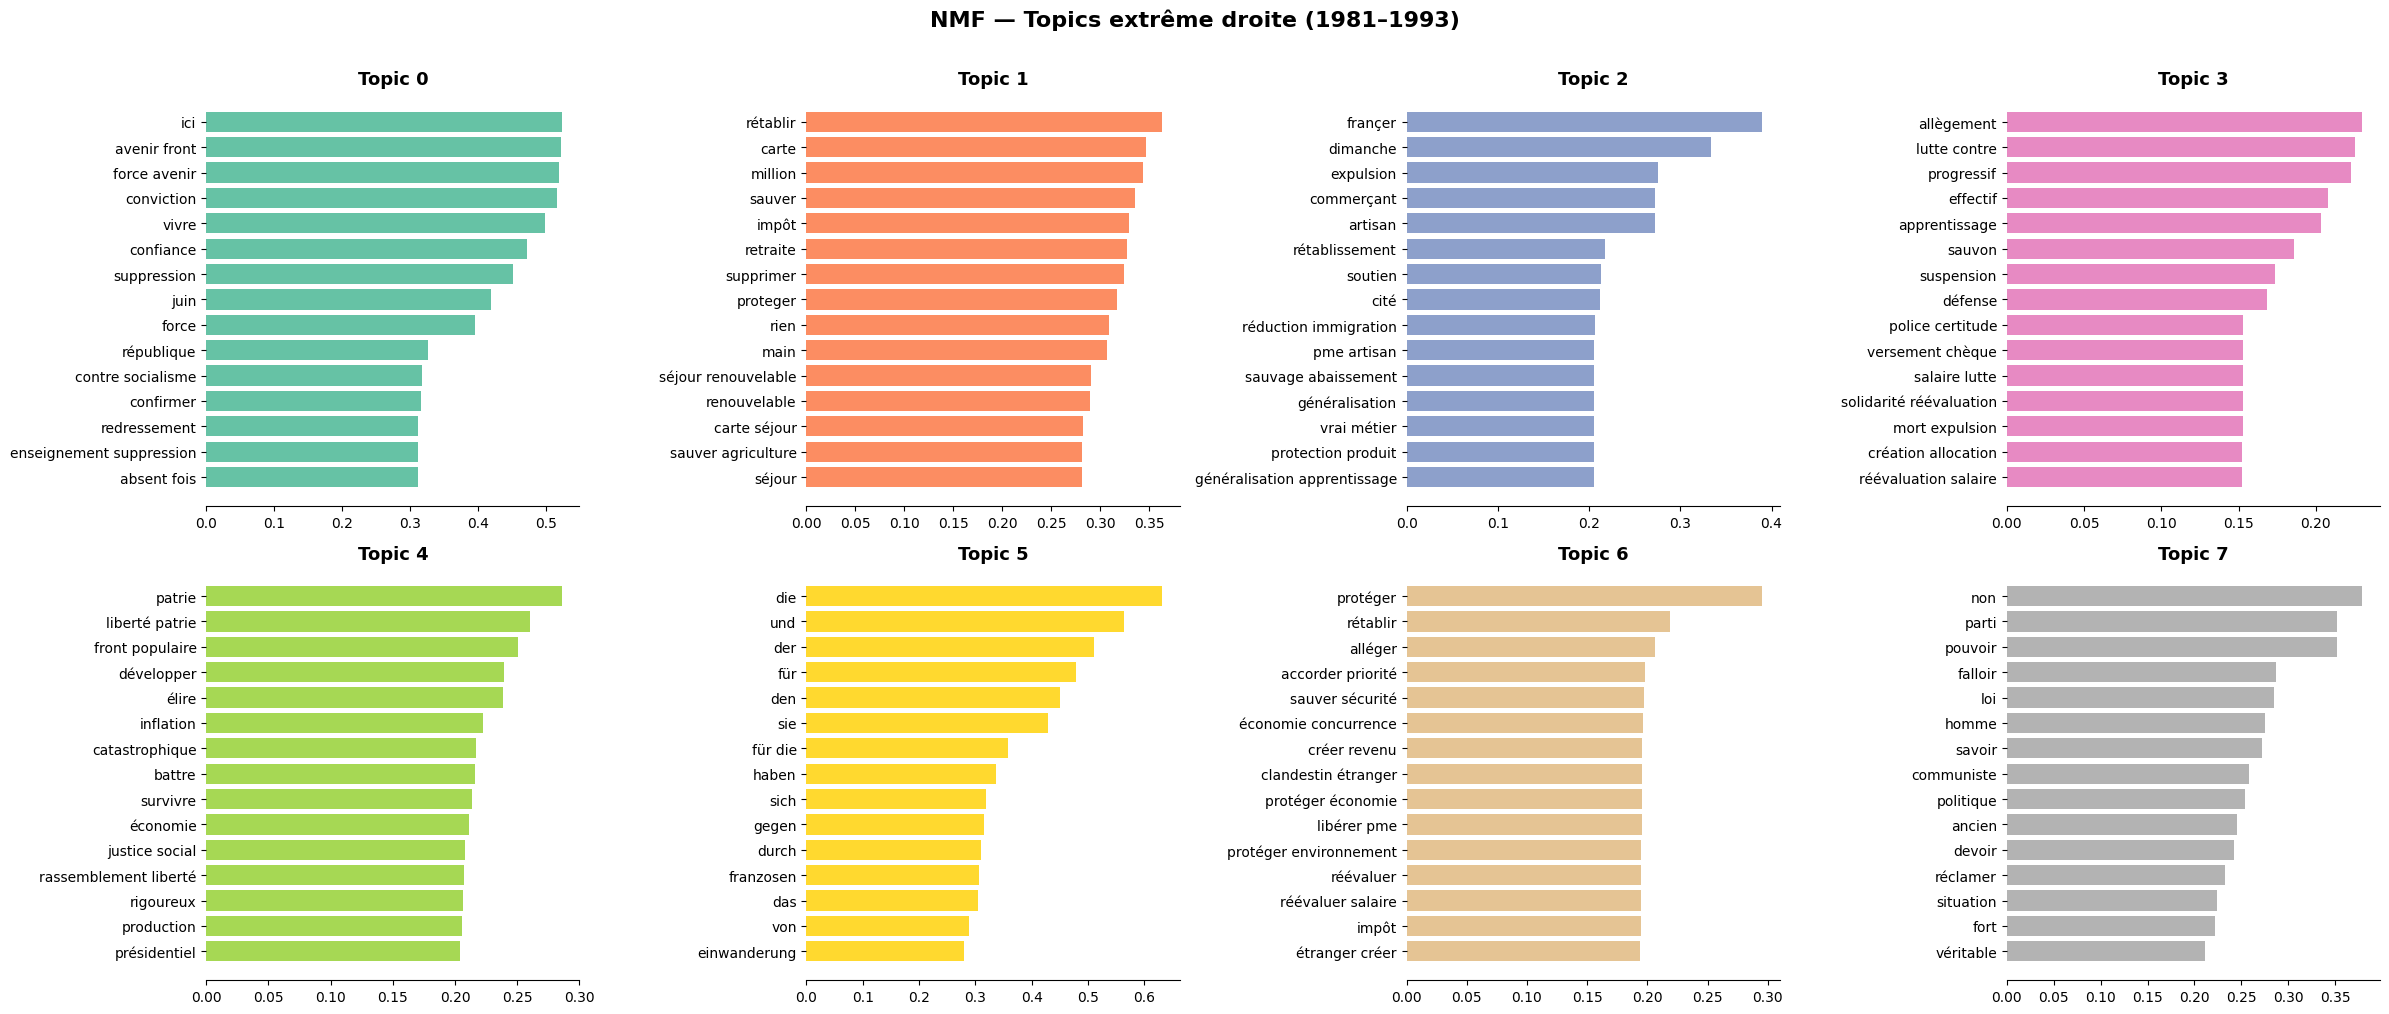

In [20]:
plot_top_words(nmf, tfidf_vectorizer, 15,
               "NMF — Topics extrême droite (1981–1993)")

In [ ]:
# ── Étiquetage manuel des topics pour les visualisations suivantes ──────────────────────────────────────────────
topic_labels = {
    0: 'Valeurs',
    1: 'Fiscalité',
    2: 'Population cicle',
    3: 'Sauvegarde des valeurs',
    4: 'Patrie',
    5: 'Allemand',
    6: 'Protéger',
    7: 'Politique',
}

Rappel des top-8 mots par topic :
  T0 [Valeurs                       ] → ici, avenir front, force avenir, conviction, vivre, confiance, suppression, juin
  T1 [Fiscalité                     ] → rétablir, carte, million, sauver, impôt, retraite, supprimer, proteger
  T2 [Population cicle              ] → françer, dimanche, expulsion, commerçant, artisan, rétablissement, soutien, cité
  T3 [Sauvegarde des valeurs        ] → allègement, lutte contre, progressif, effectif, apprentissage, sauvon, suspension, défense
  T4 [Patrie                        ] → patrie, liberté patrie, front populaire, développer, élire, inflation, catastrophique, battre
  T5 [Allemand                      ] → die, und, der, für, den, sie, für die, haben
  T6 [Protéger                      ] → protéger, rétablir, alléger, accorder priorité, sauver sécurité, économie concurrence, créer revenu, clandestin étranger
  T7 [Politique                     ] → non, parti, pouvoir, falloir, loi, homme, savoir, communiste


---
## Étape 6 — Analyse temporelle : évolution des topics 1981 → 1988 → 1993

La matrice W donne le poids de chaque topic dans chaque document. En agrégeant par année, on peut observer si certains thèmes montent, descendent ou disparaissent.

In [ ]:
# ── Normalisation de W ────────────────────────────────────────────────────────
# On normalise chaque ligne pour avoir des proportions (somme = 1 par document)
W_norm = W / W.sum(axis=1, keepdims=True)

# Ajouter au DataFrame
for t in range(N_TOPICS):
    df_ed[f't{t}'] = W_norm[:, t]
df_ed['dominant_topic']       = np.argmax(W_norm, axis=1)
df_ed['dominant_score']       = np.max(W_norm, axis=1)
df_ed['dominant_label']       = df_ed['dominant_topic'].map(topic_labels)

# ── Poids moyen par topic et par année ────────────────────────────────────────
topic_cols = [f't{t}' for t in range(N_TOPICS)]
by_year    = df_ed.groupby('year')[topic_cols].mean()
by_year.columns = [f"T{t}: {topic_labels[t]}" for t in range(N_TOPICS)]

print("Importance moyenne des topics par année :")
print(by_year.round(3).to_string())

Importance moyenne des topics par année :
      T0: Valeurs  T1: Fiscalité  T2: Population cicle  T3: Sauvegarde des valeurs  T4: Patrie  T5: Allemand  T6: Protéger  T7: Politique
year                                                                                                                                     
1981        0.003          0.000                 0.001                       0.001       0.646         0.000         0.001          0.346
1988        0.899          0.001                 0.005                       0.003       0.005         0.032         0.003          0.053
1993        0.002          0.558                 0.110                       0.082       0.004         0.024         0.131          0.089


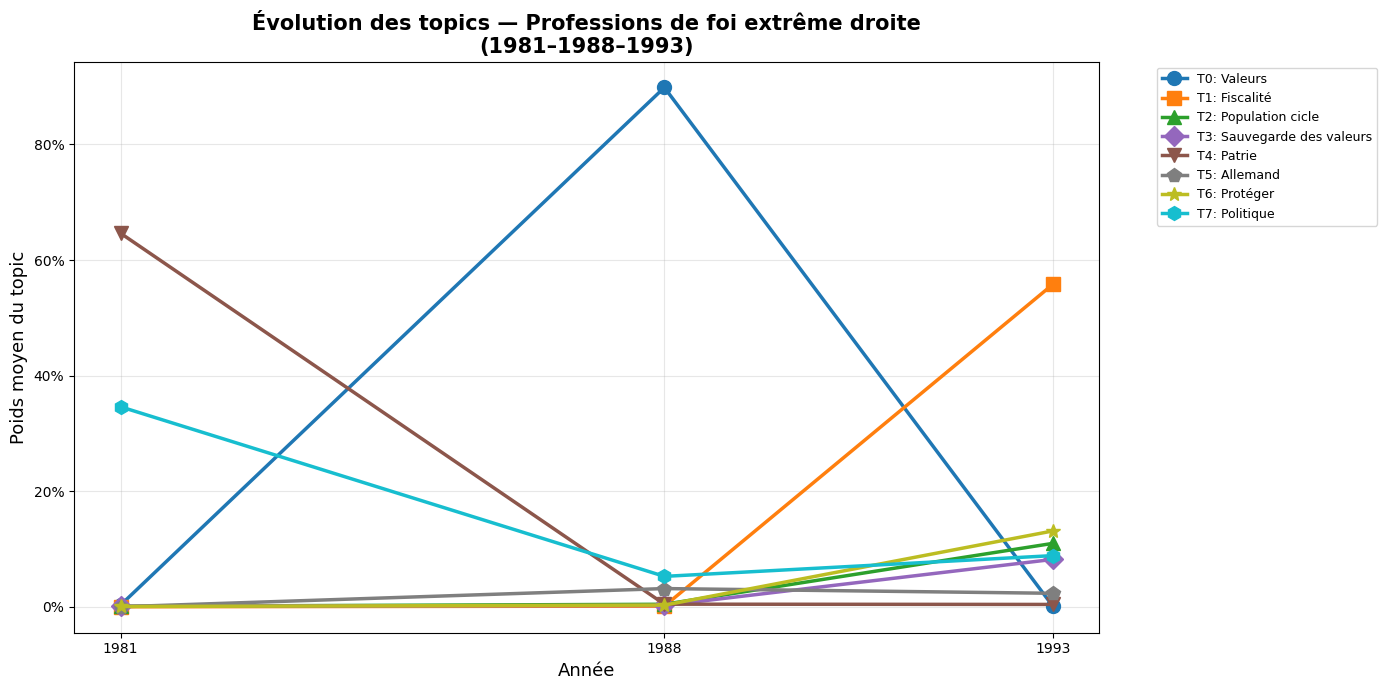

In [24]:
# ── Graphique 1 : évolution par topic (courbes) ───────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
pal     = plt.cm.tab10(np.linspace(0, 1, N_TOPICS))
mkrs    = ['o','s','^','D','v','p','*','h']
years_avail = sorted(by_year.index.tolist())

for i, col in enumerate(by_year.columns):
    ax.plot(years_avail, by_year.loc[years_avail, col],
            marker=mkrs[i % len(mkrs)], lw=2.5, ms=10,
            label=col, color=pal[i])

ax.set_xticks(years_avail)
ax.set_xlabel('Année', fontsize=13)
ax.set_ylabel('Poids moyen du topic', fontsize=13)
ax.set_title('Évolution des topics — Professions de foi extrême droite\n(1981–1988–1993)',
             fontsize=15, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('topic_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

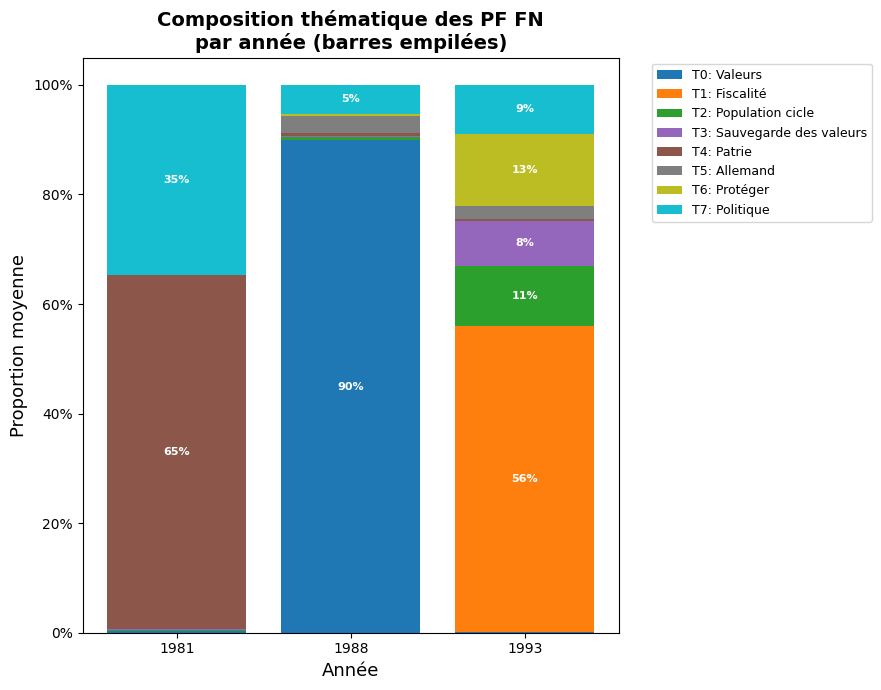

In [25]:
# ── Graphique 2 : barres empilées — composition thématique par année ──────────
fig, ax = plt.subplots(figsize=(9, 7))
bottom  = np.zeros(len(years_avail))
xlabels = [str(y) for y in years_avail]

for i, col in enumerate(by_year.columns):
    vals = by_year.loc[years_avail, col].values
    ax.bar(xlabels, vals, bottom=bottom, label=col, color=pal[i])
    # Afficher le % si la part est suffisamment grande
    for xi, (v, b) in enumerate(zip(vals, bottom)):
        if v > 0.04:
            ax.text(xi, b + v/2, f'{v:.0%}', ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')
    bottom += vals

ax.set_xlabel('Année', fontsize=13)
ax.set_ylabel('Proportion moyenne', fontsize=13)
ax.set_title('Composition thématique des PF FN\npar année (barres empilées)',
             fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0, 1.05)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('topic_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Validation qualitative ────────────────────────────────────────────────────
# On inspecte les documents et leur classification respective
def show_top_docs(df, W_norm, t_idx, label, n=2):
    print(f"\n{'='*65}")
    print(f" TOPIC {t_idx} : {label}")
    print(f"{'='*65}")
    for doc_idx in np.argsort(-W_norm[:, t_idx])[:n]:
        row = df.iloc[doc_idx]
        print(f"\n  [{row['year']} | Dep {row['dep']:03d} | Circ {row['circ']:02d} "
              f"| poids topic : {W_norm[doc_idx, t_idx]:.1%}]")
        print(textwrap.fill(row['text'][:700], width=88))

for t in range(N_TOPICS):
    show_top_docs(df_ed, W_norm, t, topic_labels[t], n=1)


 TOPIC 0 : Valeurs

  [1988 | Dep 001 | Circ 03 | poids topic : 100.0%]
Élections Législatives du 5 Juin 1988 - Département de l'Ain - 3e circonscription
Sciences Po / fonds CEVIPOF Maintenant la force d'avenir c'est le Front National Appel
aux Français, Le 24 Avril, 4.400.000 électrices et électeurs m'ont fait confiance : -
pour promouvoir le programme de redressement national, - pour réduire le chômage,
l'immigration, l'insécurité, ; pour lutter contre le socialisme bureaucratique et
fiscaliste. Je leur demande de confirmer et d'amplifier leur vote le 5 juin prochain. La
réélection de François MITTERRAND a été rendue possible par les erreurs et les
faiblesses du RPR et de l'UDF ainsi que par leur attitude d'exclusion à l'égard du Front
National. Ne faites pas

 TOPIC 1 : Fiscalité

  [1993 | Dep 014 | Circ 04 | poids topic : 100.0%]
Sciences Po / fonds CEVIPOF ÉLECTIONS LÉGISLATIVES DE MARS 1993 - 4ème CIRCONSCRIPTION
DU CALVADOS FRONT NATIONAL LES FRANÇAIS D'ABORD ! avec Jean-Marie

---
## Étape 7 — NMF séparé par année

Pour détecter les thèmes **spécifiques à chaque élection**, on entraîne un NMF indépendant par année. Cela permet de voir des topics émergents en 1993 (ex: Maastricht) qui n'auraient pas de poids suffisant dans le modèle global.

In [27]:
N_T_YEAR = 5   # moins de topics car sous-corpus plus petits

for year in YEARS:
    sub = df_ed[df_ed['year'] == year]
    n   = len(sub)
    print(f"\n{'─'*60}")
    print(f" {year} — {n} professions de foi")
    print(f"{'─'*60}")

    if n < 10:
        # Corpus trop petit → afficher simplement les mots les plus fréquents
        print(f"  Corpus trop petit pour NMF ({n} docs).")
        print("  Mots les plus fréquents (hors stopwords) :")
        words = [w for t in sub['text_lemmatized'] for w in t.split()
                 if w not in ALL_SW and len(w) >= 4]
        top20 = [w for w, _ in Counter(words).most_common(20)]
        print(f"  {', '.join(top20)}")
        continue

    vec = TfidfVectorizer(
        max_features=800, stop_words=list(ALL_SW),
        min_df=2, max_df=0.95, ngram_range=(1, 2)
    )
    mat = vec.fit_transform(sub['text_lemmatized'])

    nmf_y = NMF(n_components=N_T_YEAR, init='nndsvda', random_state=42)
    nmf_y.fit(mat)

    fn_y = vec.get_feature_names_out()
    for t_idx, topic in enumerate(nmf_y.components_):
        top = [fn_y[j] for j in np.argsort(-topic)[:12]]
        print(f"  Topic {t_idx} : {', '.join(top)}")


────────────────────────────────────────────────────────────
 1981 — 58 professions de foi
────────────────────────────────────────────────────────────
  Topic 0 : front, public, social, populaire, économie, front populaire, patrie, élire, développer, famille, liberté patrie, battre
  Topic 1 : savoir, gauche, opposer, pouvoir, réclamer, combattre, lutter, idée, faire, information, campagne, volonté
  Topic 2 : appel, réaliser, rassemblement national, chirac, national appel, objectif, droite national, électoral, lecanuet, courant, inverser, ignorer
  Topic 3 : françois, parti force, parti, force, union, emploi, union droite, droite parti, montrez, françois mitterrand, public, moyen
  Topic 4 : front, front national, patrie, marier enfant, paris, militaire, marier, ancien, pouvoir, rassemblement, enfant, droit


c:\Users\jonas\OneDrive - GENES\Documents\0 ENSAE\3A\S2\ML_for_NLP\NLP_project\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['neuf', 'qu', 'quelqu'] not in stop_words.
  warnings.warn(
c:\Users\jonas\OneDrive - GENES\Documents\0 ENSAE\3A\S2\ML_for_NLP\NLP_project\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['neuf', 'qu', 'quelqu'] not in stop_words.
  warnings.warn(



────────────────────────────────────────────────────────────
 1988 — 548 professions de foi
────────────────────────────────────────────────────────────
  Topic 0 : populaire national, entente, lepen populaire, remplaçant, éventuel, remplaçant éventuel, république jemenin, jemenin, enfant, udf joindre, entendre contre, carrière pareil
  Topic 1 : die, der, und, für, den, für die, sie, sich, haben, wählt, ihr, gegen
  Topic 2 : paris, clergerie paris, général clergerie, rue général, général, clergerie, écrir rue, nationale, rue, populaire nationale, legislatives, écrir
  Topic 3 : croix, militaire, honneur, légion, légion honneur, officier, chevalier, médaille, guerre, ancien, fiscal, jacques
  Topic 4 : amplifiez, amplifiez pen, socialisme confirmer, avenir contre, pen présent, perdant, perdant avenir, confirmer amplifiez, confiance perdant, paris imp, imp source, source

────────────────────────────────────────────────────────────
 1993 — 651 professions de foi
──────────────────────

c:\Users\jonas\OneDrive - GENES\Documents\0 ENSAE\3A\S2\ML_for_NLP\NLP_project\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['neuf', 'qu', 'quelqu'] not in stop_words.
  warnings.warn(


  Topic 0 : udf, rpr udf, rétablir, voix, million, carte, sauver, retraite, supprimer, contre, immigré, rien
  Topic 1 : françer, dimanche, priorité, drogue, confiance, commerçant, artisan, pouvoir, expulsion, étranger, réduction, cercle
  Topic 2 : suppression, lutte, création, progressif, effectif, lutte contre, allègement, droit, défense, sauvon, réduction, apprentissage
  Topic 3 : die, der, und, sie, den, für, von, franzosen, das, durch, eine, gegen
  Topic 4 : protéger, udf, rétablir, rpr udf, million, immigré, créer, alléger, sécurité social, sauver, retraite, contre


---
## Étape 8 — BERTopic + Topics Over Time

BERTopic utilise des **embeddings contextuels** (transformers) plutôt que des fréquences de mots. Il peut détecter des similarités sémantiques que LDA/NMF ratent (ex : deux PF qui parlent du même sujet avec des mots différents).

La fonctionnalité **Topics Over Time** calcule directement l'évolution de chaque topic sur la timeline 1981→1988→1993.

In [30]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer as CV_bert

docs       = df_ed['text_clean'].tolist()    # texte nettoyé (pas lemmatisé)
timestamps = df_ed['year'].tolist()

# ── 1. Embeddings sémantiques ─────────────────────────────────────────────────
# Modèle multilingue léger — bon compromis vitesse/qualité pour le français
print("Encodage des documents...")
emb_model  = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
embeddings = emb_model.encode(docs, show_progress_bar=True, batch_size=32)
print(f"Embeddings : {embeddings.shape}")

# ── 2. CountVectorizer pour les labels de topics ──────────────────────────────
vec_bert = CV_bert(stop_words=list(ALL_SW), min_df=2, ngram_range=(1, 2))

# ── 3. BERTopic ───────────────────────────────────────────────────────────────
# min_topic_size : baisser si corpus petit (ex: 5–10)
# nr_topics='auto' : fusionne automatiquement les topics trop similaires
topic_model = BERTopic(
    language='french',
    vectorizer_model=vec_bert,
    min_topic_size=5,
    nr_topics='auto',
    verbose=True
)
topics, probs = topic_model.fit_transform(docs, embeddings)

info = topic_model.get_topic_info()
print(f"\n✅ {len(info)} topics découverts | {topics.count(-1)} outliers (topic -1)")
print(info[info['Topic'] != -1].to_string())

Encodage des documents...


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/40 [00:00<?, ?it/s]

Embeddings : (1257, 384)


2026-03-13 13:59:26,148 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-13 13:59:48,742 - BERTopic - Dimensionality - Completed ✓
2026-03-13 13:59:48,744 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-13 13:59:48,804 - BERTopic - Cluster - Completed ✓
2026-03-13 13:59:48,804 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-03-13 13:59:49,963 - BERTopic - Representation - Completed ✓
2026-03-13 13:59:49,978 - BERTopic - Topic reduction - Reducing number of topics
2026-03-13 13:59:49,994 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-13 13:59:51,152 - BERTopic - Representation - Completed ✓
2026-03-13 13:59:51,158 - BERTopic - Topic reduction - Reduced number of topics from 50 to 3



✅ 3 topics découverts | 317 outliers (topic -1)
   Topic  Count                                 Name                                                                            Representation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

In [31]:
# ── Topics Over Time ──────────────────────────────────────────────────────────
# Calcule l'importance de chaque topic par période.
# C'est la réponse directe à "y a-t-il une évolution entre 1981, 1988 et 1993 ?"
tot = topic_model.topics_over_time(
    docs=docs, timestamps=timestamps,
    nr_bins=3,            # 3 périodes = une par année
    evolution_tuning=True  # lissage entre périodes
)

top_topics = [t for t in info[info['Topic'] != -1]['Topic'].values[:8]]
fig = topic_model.visualize_topics_over_time(
    tot, topics=top_topics,
    title='Topics BERTopic — PF extrême droite (1981–1988–1993)'
)
fig.show()

3it [00:01,  2.97it/s]


In [32]:
# ── Carte 2D des documents ────────────────────────────────────────────────────
# Chaque point = une PF ; documents proches = sémantiquement similaires
topic_model.visualize_documents(
    docs=docs, embeddings=embeddings,
    topics=top_topics,
    hide_annotations=False,
    height=700, width=1100,
    title='Carte sémantique des PF FN (1981–1988–1993)'
)

---
## Étape 9 (Extra) — Sélection du nombre optimal de topics

Les métriques de **cohérence** permettent de choisir k de façon rigoureuse. On cherche le "coude" où la cohérence stagne ou diminue.

In [ ]:
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

# Tokenisation pour Gensim (listes de tokens, pas de strings)
analyzer = tfidf_vectorizer.build_analyzer()
tok_texts = [analyzer(t) for t in df_ed['text_lemmatized']]
dct = Dictionary(tok_texts)
dct.filter_extremes(no_below=3, no_above=0.95)
print(f"Dictionnaire Gensim : {len(dct)} termes")

def top_words_list(model, fn, n=10):
    return [[fn[j] for j in np.argsort(-t)[:n]] for t in model.components_]

topic_range = [3, 5, 7, 10, 12, 15]
metrics     = ['c_v', 'u_mass', 'c_npmi']
results     = {m: {} for m in metrics}
fn_t        = tfidf_vectorizer.get_feature_names_out()

for k in topic_range:
    nmf_k = NMF(n_components=k, init='nndsvda', random_state=42)
    nmf_k.fit(tfidf_matrix)
    topics_k = top_words_list(nmf_k, fn_t)
    print(f"k={k:2d} ", end='')
    for m in metrics:
        try:
            s = CoherenceModel(topics=topics_k, texts=tok_texts,
                               dictionary=dct, coherence=m).get_coherence()
        except Exception:
            s = np.nan
        results[m][k] = s
        print(f"{m}={s:.3f}  ", end='')
    print()

# Graphique
fig, ax = plt.subplots(figsize=(10, 5))
for m in metrics:
    ks = sorted(results[m])
    sc = np.array([results[m][k] for k in ks])
    v  = ~np.isnan(sc)
    if v.sum() > 1:
        mn, mx = sc[v].min(), sc[v].max()
        norm = (sc - mn) / (mx - mn) if mx > mn else np.zeros_like(sc)
        ax.plot(ks, norm, marker='o', lw=2, label=m)
ax.set_xlabel('Nombre de topics (k)') ; ax.set_ylabel('Cohérence normalisée [0,1]')
ax.set_title('Choix du nombre optimal de topics — NMF', fontweight='bold')
ax.set_xticks(topic_range) ; ax.grid(True, alpha=0.3) ; ax.legend()
plt.tight_layout()
plt.savefig('coherence.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nMeilleur k par métrique :")
for m in metrics:
    ks = sorted(results[m])
    valid = [(k, results[m][k]) for k in ks if not np.isnan(results[m][k])]
    if valid:
        best = max(valid, key=lambda x: x[1])
        print(f"  {m} : k={best[0]}  (score={best[1]:.4f})")

---
## Étape 10 — Synthèse : mots distinctifs par année

Pour compléter l'analyse, on calcule les mots les plus **caractéristiques de chaque année** en traitant chaque année comme un mega-document et en calculant un TF-IDF inter-années. Un score élevé pour 1993 = ce mot est utilisé *surtout* en 1993.

In [ ]:
year_mega = {y: ' '.join(df_ed[df_ed['year']==y]['text_lemmatized'].tolist())
             for y in YEARS if (df_ed['year']==y).sum() > 0}

if len(year_mega) >= 2:
    ys  = sorted(year_mega)
    vec = TfidfVectorizer(max_features=400, stop_words=list(ALL_SW), min_df=1)
    mat = vec.fit_transform([year_mega[y] for y in ys])
    fn  = vec.get_feature_names_out()

    print("MOTS LES PLUS DISTINCTIFS PAR ANNÉE")
    print("(TF-IDF inter-années : score élevé = utilisé surtout cette année-là)")
    for i, year in enumerate(ys):
        sc   = mat[i].toarray().flatten()
        top  = [fn[j] for j in np.argsort(-sc)[:25] if sc[j] > 0]
        n_docs = (df_ed['year'] == year).sum()
        print(f"\n{'='*55}")
        print(f" {year}  ({n_docs} PF) :")
        print(f"{'='*55}")
        for k in range(0, len(top), 5):
            print('  ' + '  |  '.join(top[k:k+5]))

print("""
💡 GUIDE D'INTERPRÉTATION

• PERSISTANCES : topics présents dans les 3 années
  → Noyau dur de l'idéologie frontiste
  → Probables : anti-communisme, ordre, famille, identité nationale

• MONTÉES : topics dont le poids augmente de 1981 à 1993
  → 1981→1988 : montée de l'immigration et de l'insécurité
     (après le 1er succès de Le Pen aux européennes 1984)
  → 1988→1993 : Europe / Maastricht, anti-establishment

• RUPTURES : topics absents avant une date
  → 1993 : traité de Maastricht (sept. 1992), référendum serré
     → probable émergence d'un topic souverainiste/eurosceptique

Références bibliographiques :
  - Nonna Mayer & Pascal Perrineau, Le Front National à découvert (1996)
  - Jean-Yves Camus & René Monzat, Les droites nationales (1992)
  - Pierre Birnbaum, Le peuple et le roi (1979)
""")

In [ ]:
# ── Export des résultats ──────────────────────────────────────────────────────
cols_export = (['year','filename','dep','circ','tour','text_length',
                'ed_confidence','dominant_topic','dominant_label','dominant_score']
               + [f't{t}' for t in range(N_TOPICS)])

df_ed[cols_export].to_csv('archelec_resultats.csv', index=False, encoding='utf-8')

summary = pd.DataFrame([{
    'topic_id'   : t,
    'label'      : topic_labels[t],
    'top_words'  : ', '.join([fn_tfidf[j] for j in np.argsort(-nmf.components_[t])[:15]]),
    'n_dominant' : (df_ed['dominant_topic'] == t).sum()
} for t in range(N_TOPICS)])
summary.to_csv('archelec_topics.csv', index=False, encoding='utf-8')

print("✅ Fichiers générés :")
for f in ['archelec_resultats.csv','archelec_topics.csv',
          'corpus_overview.png','topic_evolution.png',
          'topic_stacked.png','coherence.png']:
    print(f"  {f}")